In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import requests

from io import StringIO

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
import Estrategia
importlib.reload(Estrategia)
import Backtest
importlib.reload(Backtest)
from Backtest import *

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

EstrategiaMLEquiponderada = Estrategia.EstrategiaMLEquiponderada
EstrategiaMLMinVarAlphaTilt = Estrategia.EstrategiaMLMinVarAlphaTilt
EstrategiaMLMonteCarlo = Estrategia.EstrategiaMLMonteCarlo
EstrategiaMLEquiponderadaMacro = Estrategia.EstrategiaMLEquiponderadaMacro

### Descarga de tickers actuales del STOXX50

In [2]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()

# Modelo elegido: XGBoost con estrategia de optimización de pesos por Montecarlo

[Train] 2018-12-28 → 2022-12-23 | AUC=0.5353 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'scale_pos_weight': 3, 'subsample': 0.7}
2023-01-06 | VP=10000000 | pesos={'AI.PA': 0.039924511252437886, 'ASML.AS': 0.036856972733832837, 'BAYN.DE': 0.03784907483066011, 'DHL.DE': 0.03350134361514107, 'DTE.DE': 0.19127470354377277, 'ENI.MI': 0.09014281731322595, 'IFX.DE': 0.03102125227272201, 'MUV2.DE': 0.19127470354377277, 'NOKIA.HE': 0.06661852439413343, 'RACE.MI': 0.02909707587946378, 'RHM.DE': 0.09315641761428531, 'SAP.DE': 0.04940584608580166, 'STLAM.MI': 0.02578999829848142, 'SU.PA': 0.04804286298636062, 'VOW.DE': 0.036043895635908166}
2023-01-13 | VP=10282738 | pesos={'ADYEN.AS': 0.026616574454776457, 'ASML.AS': 0.025150816549463446, 'BAYN.DE': 0.027226976949408326, 'DHL.DE': 0.049300664179577805, 'DTE.DE': 0.15084739343542702, 'EL.PA': 0.12249511172404225, 'ENI.MI': 0.09506829238312607, 'NDA-FI.HE': 0.15112315735980159, 'NOKIA.HE': 0.034081130422

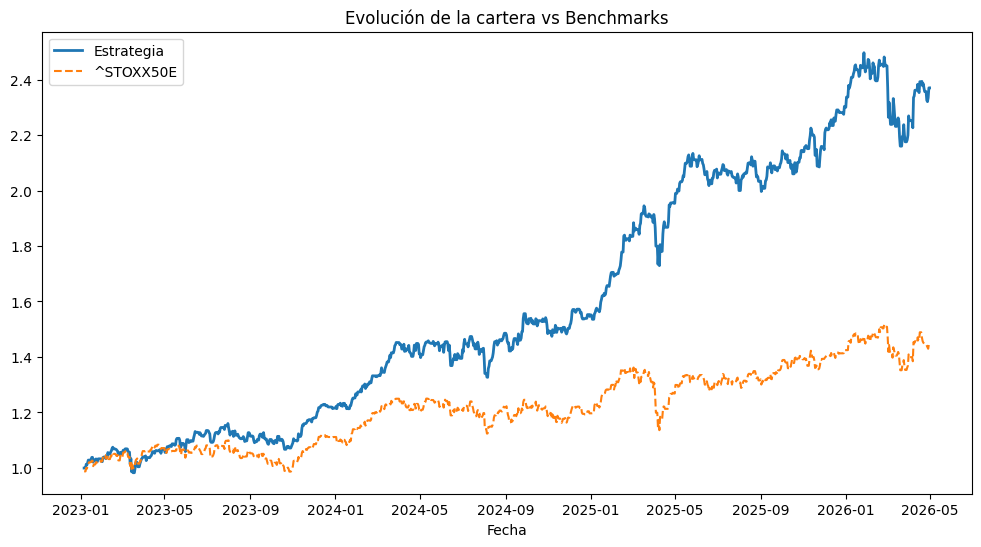

,Estrategia,^STOXX50E
Rentabilidad total,137.12%,46.39%
Rentabilidad anualizada,19.68%,8.25%
Volatilidad anualizada,13.78%,12.69%
Sharpe,1.37,0.69
Sortino,2.04,0.98
Max Drawdown,-13.49%,-16.58%
Calmar,1.46,0.50
Win rate,38.81%,36.25%
Mejor periodo,4.89%,4.97%
Peor periodo,-4.58%,-4.81%


In [3]:
start_date = "2023-01-03"
end_date = "2026-05-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=50000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

In [ ]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
provider = YFinanceProvider()

bt_random = BacktestRandom(
    universo=universo,
    proveedor=provider,
    start_date="2022-01-01",
    end_date="2024-01-01",
    nominal=100000,
    n_activos=15
)

res = bt_random.run_montecarlo(
    n_sims=100,
    benchmark="^STOXX50E"
)

plt.figure(figsize=(12, 6))
plt.plot(res["media"].index, res["media"] / res["media"].iloc[0], label="Media 100 simulaciones", linewidth=2)
plt.plot(res["benchmark"].index, res["benchmark"] / res["benchmark"].iloc[0], label="EuroStoxx 50", linestyle="--")
plt.title("Backtest aleatorio vs EuroStoxx 50")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr

[Train] 2009-01-09 → 2015-01-02 | AUC=0.5362 | {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 5, 'subsample': 0.7}
2015-01-09 | VP=10000000 | pesos={'ARGX.BR': 0.06304400086546466, 'ASML.AS': 0.15966368497038919, 'BAYN.DE': 0.10020254030539232, 'BBVA.MC': 0.042867132070472, 'BNP.PA': 0.03395453904054303, 'ENEL.MI': 0.06193894635690152, 'ENI.MI': 0.028278120838474807, 'RHM.DE': 0.04642574232041499, 'SAN.MC': 0.03194248378439305, 'SAN.PA': 0.11124389589138288, 'STLAM.MI': 0.12377244127269058, 'TEF.MC': 0.02794775934602701, 'TTE.PA': 0.02643189195323377, 'UCG.MI': 0.030137649565251487, 'VOW.DE': 0.11214917141896881}
2015-01-16 | VP=10524434 | pesos={'AD.AS': 0.035462716488534364, 'ARGX.BR': 0.16399473756537136, 'ASML.AS': 0.16399473756537136, 'BNP.PA': 0.04518983502808019, 'ENEL.MI': 0.029172719021798275, 'ENGI.PA': 0.03379243416290679, 'ENI.MI': 0.054615674246737786, 'IBE.MC': 0.07598574942698932, 'RHM.DE': 0.026484288045131005, 

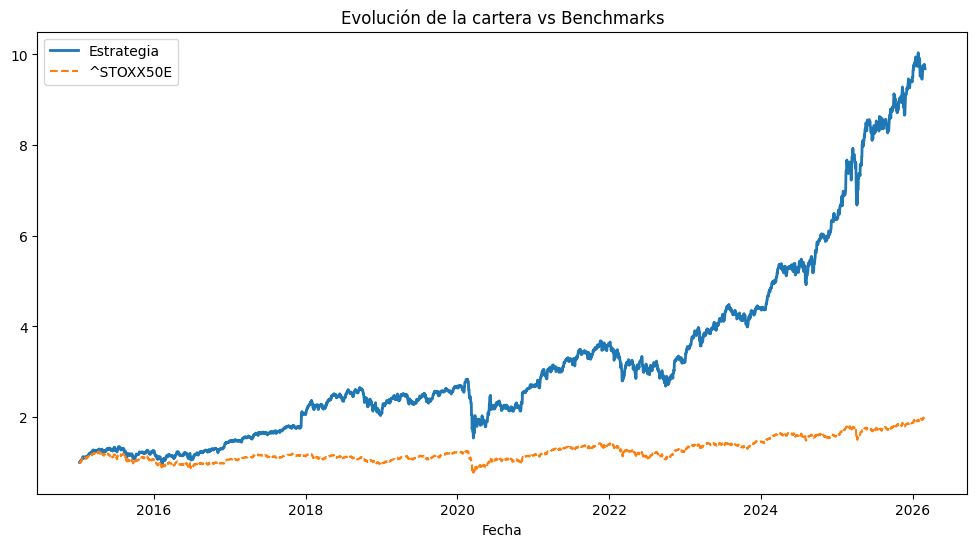

,Estrategia,^STOXX50E
Rentabilidad total,868.39%,101.73%
Rentabilidad anualizada,15.10%,4.44%
Volatilidad anualizada,19.38%,15.67%
Sharpe,0.82,0.36
Sortino,1.18,0.49
Max Drawdown,-45.82%,-38.27%
Calmar,0.33,0.12
Win rate,38.54%,36.67%
Mejor periodo,13.01%,9.24%
Peor periodo,-15.55%,-12.40%


In [5]:
start_date = "2015-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in

[Train] 2004-01-09 → 2010-01-01 | AUC=0.5156 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2010-01-08 | VP=10000000 | pesos={'ASML.AS': 0.15115233044519086, 'BAS.DE': 0.061616573552227646, 'BBVA.MC': 0.14497329023373126, 'CS.PA': 0.02366017329348456, 'DBK.DE': 0.02598076312757706, 'IBE.MC': 0.07105784025165271, 'MBG.DE': 0.03374612710495384, 'MC.PA': 0.07519379702287629, 'OR.PA': 0.059906332506551904, 'RHM.DE': 0.039909786662112264, 'RNO.PA': 0.036079238075769286, 'SAN.MC': 0.15115233044519086, 'STLAM.MI': 0.059746975053450606, 'SU.PA': 0.0429697189877668, 'VOW.DE': 0.022854723237464094}
2010-01-15 | VP=9780040 | pesos={'ADS.DE': 0.14253549878185268, 'ASML.AS': 0.11304629225423965, 'BAS.DE': 0.041705996552072036, 'BBVA.MC': 0.1181787585308085, 'DBK.DE': 0.02483202637835564, 'DHL.DE': 0.03891163873545156, 'IFX.DE': 0.06258712495699346, 'MC.PA': 0.08233609226597444, 'OR.PA': 0.05582969903035395, 'RHM.DE': 

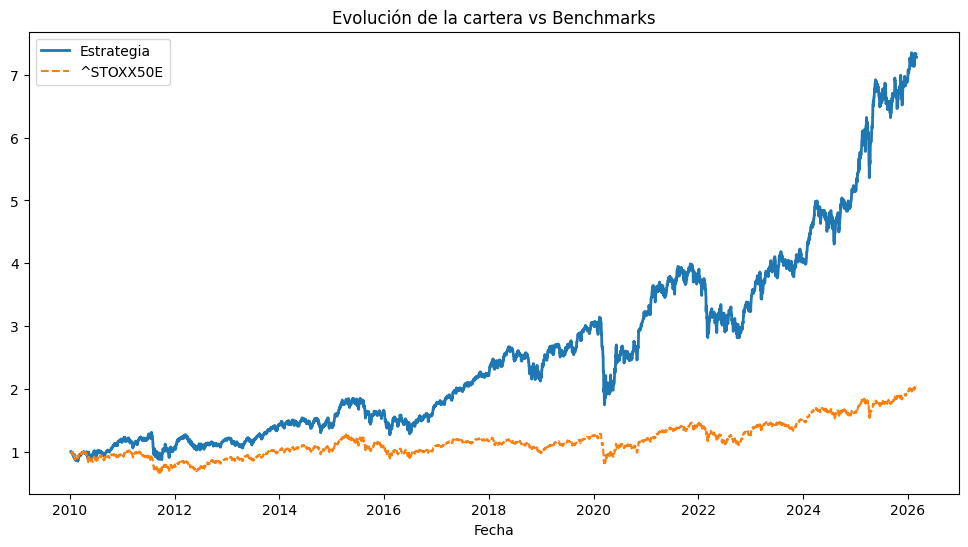

,Estrategia,^STOXX50E
Rentabilidad total,627.80%,103.40%
Rentabilidad anualizada,8.85%,3.08%
Volatilidad anualizada,19.87%,16.59%
Sharpe,0.53,0.27
Sortino,0.75,0.37
Max Drawdown,-44.52%,-38.27%
Calmar,0.20,0.08
Win rate,37.19%,36.02%
Mejor periodo,12.47%,10.35%
Peor periodo,-14.49%,-12.40%


In [ ]:
start_date = "2010-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

# Simulaciones de la estrategia de los monos locos

In [10]:
start_date = "2024-03-01"
end_date = "2026-05-01"
nominal = 10000000

universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)

proveedor = YFinanceProvider()

# Backtest monos
bt_random = BacktestRandom(
    universo=universo,
    proveedor=proveedor,
    start_date=start_date,
    end_date=end_date,
    nominal=nominal,
    n_activos=15,
    n_simulaciones_mc=1000,
)

res_random = bt_random.run_montecarlo(
    n_sims=5000,
    benchmark="^STOXX50E"
)

In [11]:
# Backtest real + monos con selección ML y pesos aleatorios

fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)

estrategia = EstrategiaMLMonteCarlo(
    modelo=modelo,
    n_activos_obj=15,
    umbral_salida=22,
    n_simulaciones=1000,   # Montecarlo interno de la estrategia real
    peso_min=0.02,
    peso_max=0.15,
)

bt_real = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=nominal,
)

serie_real, df_monos_ml_random = bt_real.run_con_monos_pesos(
    n_monos=5000,
    peso_min=0.02,
    peso_max=0.15,
    seed=42,
)

serie_real.name = "Estrategia real"

[Train] 2020-02-21 → 2024-02-16 | AUC=0.5351 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 5, 'subsample': 1.0}
2024-03-01 | VP real=9,995,004 | activos=['ABI.BR', 'AD.AS', 'ADS.DE', 'ADYEN.AS', 'ASML.AS', 'BAS.DE', 'BAYN.DE', 'BNP.PA', 'ENEL.MI', 'IFX.DE', 'MC.PA', 'PRX.AS', 'RHM.DE', 'SAN.MC', 'SAN.PA']
2024-03-08 | VP real=10,129,149 | activos=['AD.AS', 'ADS.DE', 'ADYEN.AS', 'ASML.AS', 'BAYN.DE', 'BNP.PA', 'DG.PA', 'ENEL.MI', 'IBE.MC', 'IFX.DE', 'MC.PA', 'PRX.AS', 'RHM.DE', 'SAN.MC', 'SAN.PA']
2024-03-15 | VP real=10,235,693 | activos=['ADYEN.AS', 'ASML.AS', 'BAYN.DE', 'BN.PA', 'BNP.PA', 'ENEL.MI', 'IBE.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'PRX.AS', 'RHM.DE', 'SAN.PA', 'TTE.PA', 'UCG.MI']
2024-03-22 | VP real=10,493,116 | activos=['ADS.DE', 'ADYEN.AS', 'ASML.AS', 'BAYN.DE', 'BN.PA', 'BNP.PA', 'DHL.DE', 'ENEL.MI', 'IBE.MC', 'IFX.DE', 'PRX.AS', 'RHM.DE', 'SAN.PA', 'TTE.PA', 'UCG.MI']
2024-03-29 | VP real=10,759,909 | activos

In [12]:
# Cuántos monos ganan
df_random = res_random["pesos_random"]["todas"]
df_mc = res_random["pesos_mc"]["todas"]
df_ml_random = df_monos_ml_random

idx = (
    df_random.index
    .union(df_mc.index)
    .union(df_ml_random.index)
    .union(serie_real.index)
    .sort_values()
)

df_random = df_random.reindex(idx).ffill()
df_mc = df_mc.reindex(idx).ffill()
df_ml_random = df_ml_random.reindex(idx).ffill()
serie_real_aligned = serie_real.reindex(idx).ffill()

valor_final_real = serie_real_aligned.iloc[-1]

final_random = df_random.iloc[-1]
final_mc = df_mc.iloc[-1]
final_ml_random = df_ml_random.iloc[-1]

n_random = len(final_random)
n_mc = len(final_mc)
n_ml_random = len(final_ml_random)

n_random_ganan = int((final_random > valor_final_real).sum())
n_mc_ganan = int((final_mc > valor_final_real).sum())
n_ml_random_ganan = int((final_ml_random > valor_final_real).sum())

n_total = n_random + n_mc + n_ml_random
n_total_ganan = n_random_ganan + n_mc_ganan + n_ml_random_ganan

print(f"Valor final estrategia real: {valor_final_real:,.2f} €")
print()
print(f"Monos random puro que ganan: {n_random_ganan} / {n_random} ({n_random_ganan / n_random:.2%})")
print(f"Monos random + MC pesos que ganan: {n_mc_ganan} / {n_mc} ({n_mc_ganan / n_mc:.2%})")
print(f"Monos ML + pesos random que ganan: {n_ml_random_ganan} / {n_ml_random} ({n_ml_random_ganan / n_ml_random:.2%})")
print()
print(f"Total monos que ganan: {n_total_ganan} / {n_total} ({n_total_ganan / n_total:.2%})")

Valor final estrategia real: 17,660,529.47 €

Monos random puro que ganan: 0 / 5000 (0.00%)
Monos random + MC pesos que ganan: 6 / 5000 (0.12%)
Monos ML + pesos random que ganan: 0 / 5000 (0.00%)

Total monos que ganan: 6 / 15000 (0.04%)


In [13]:
# Ranking y percentiles
finales_todos = pd.concat([
    final_random.rename("Random puro"),
    final_mc.rename("Random + MC pesos"),
    final_ml_random.rename("ML + pesos random"),
])

ranking_real = int((finales_todos > valor_final_real).sum() + 1)
percentil_real = 1 - (ranking_real - 1) / len(finales_todos)

print(f"Ranking estrategia real: {ranking_real} de {len(finales_todos) + 1}")
print(f"Percentil estrategia real: {percentil_real:.2%}")

Ranking estrategia real: 7 de 15001
Percentil estrategia real: 99.96%


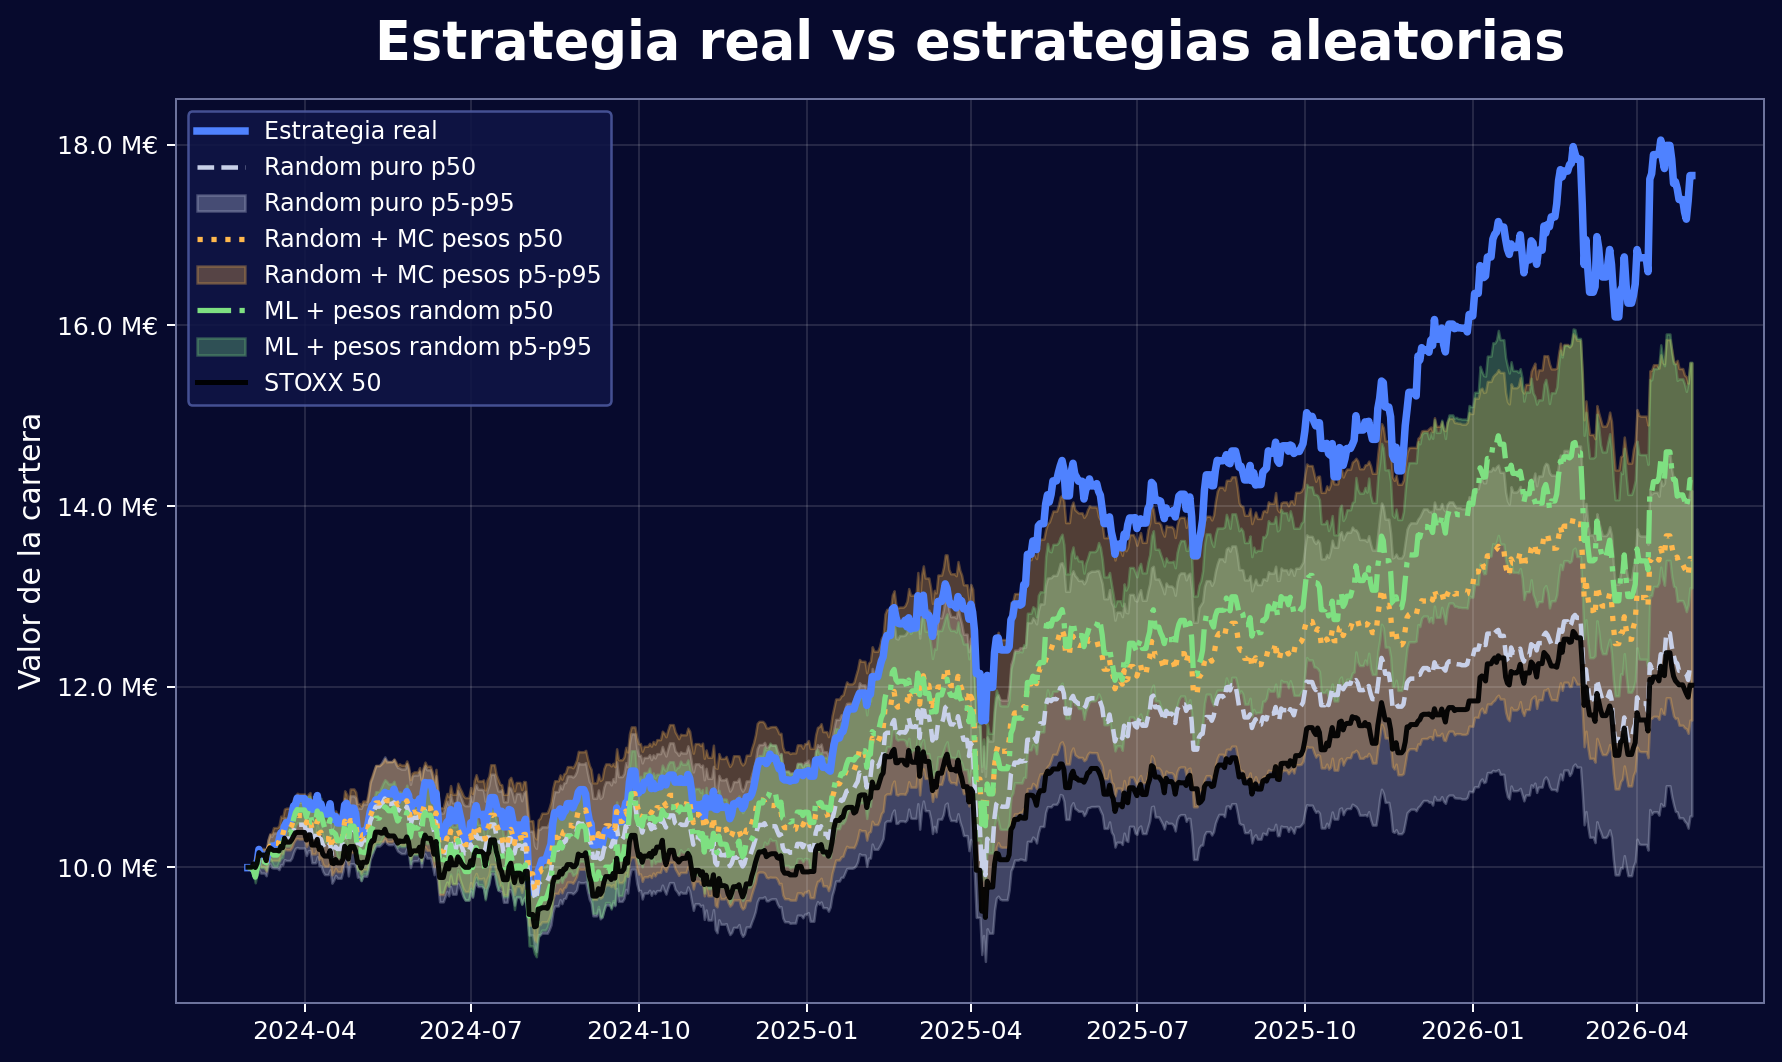

In [28]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def formato_euros_millones(x, pos):
    return f"{x / 1_000_000:.1f} M€"

fondo = "#070A2D"
azul = "#4F82FF"
turquesa = "#2FE6D0"
naranja = "#FFB84D"
verde = "#7EE081"
gris = "#C8D0E8"
blanco = "white"

p_random = {
    "p5": df_random.quantile(0.05, axis=1),
    "p50": df_random.quantile(0.50, axis=1),
    "p95": df_random.quantile(0.95, axis=1),
}

p_mc = {
    "p5": df_mc.quantile(0.05, axis=1),
    "p50": df_mc.quantile(0.50, axis=1),
    "p95": df_mc.quantile(0.95, axis=1),
}

p_ml_random = {
    "p5": df_ml_random.quantile(0.05, axis=1),
    "p50": df_ml_random.quantile(0.50, axis=1),
    "p95": df_ml_random.quantile(0.95, axis=1),
}

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
fig.patch.set_facecolor(fondo)
ax.set_facecolor(fondo)

ax.plot(
    serie_real_aligned.index,
    serie_real_aligned,
    label="Estrategia real",
    color=azul,
    linewidth=3.0,
)

ax.plot(
    p_random["p50"].index,
    p_random["p50"],
    label="Random puro p50",
    color=gris,
    linestyle="--",
    linewidth=1.8,
)
ax.fill_between(
    p_random["p5"].index,
    p_random["p5"],
    p_random["p95"],
    color=gris,
    alpha=0.3,
    label="Random puro p5-p95",
)

ax.plot(
    p_mc["p50"].index,
    p_mc["p50"],
    label="Random + MC pesos p50",
    color=naranja,
    linestyle=":",
    linewidth=2.1,
)
ax.fill_between(
    p_mc["p5"].index,
    p_mc["p5"],
    p_mc["p95"],
    color=naranja,
    alpha=0.3,
    label="Random + MC pesos p5-p95",
)

ax.plot(
    p_ml_random["p50"].index,
    p_ml_random["p50"],
    label="ML + pesos random p50",
    color=verde,
    linestyle="-.",
    linewidth=2.1,
)
ax.fill_between(
    p_ml_random["p5"].index,
    p_ml_random["p5"],
    p_ml_random["p95"],
    color=verde,
    alpha=0.3,
    label="ML + pesos random p5-p95",
)

if "benchmark" in res_random:
    benchmark = res_random["benchmark"].reindex(idx).ffill()
    ax.plot(
        benchmark.index,
        benchmark,
        label="STOXX 50",
        color="#000000",
        linewidth=2.0,
        alpha=0.95,
    )

ax.set_title(
    "Estrategia real vs estrategias aleatorias",
    color=blanco,
    fontsize=21,
    fontweight="bold",
    pad=16,
)

ax.set_ylabel("Valor de la cartera", color=blanco, fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(formato_euros_millones))

ax.grid(True, color=blanco, alpha=0.12, linewidth=0.8)
ax.tick_params(colors=blanco, labelsize=10)

for spine in ax.spines.values():
    spine.set_color("#6D739C")

leg = ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=9.5,
)
leg.get_frame().set_facecolor("#101545")
leg.get_frame().set_edgecolor("#4D5AA0")
leg.get_frame().set_alpha(0.88)

for text in leg.get_texts():
    text.set_color(blanco)

plt.tight_layout()
plt.savefig("grafico_monos_evolucion.png", dpi=300, bbox_inches="tight", facecolor=fondo)
plt.show()

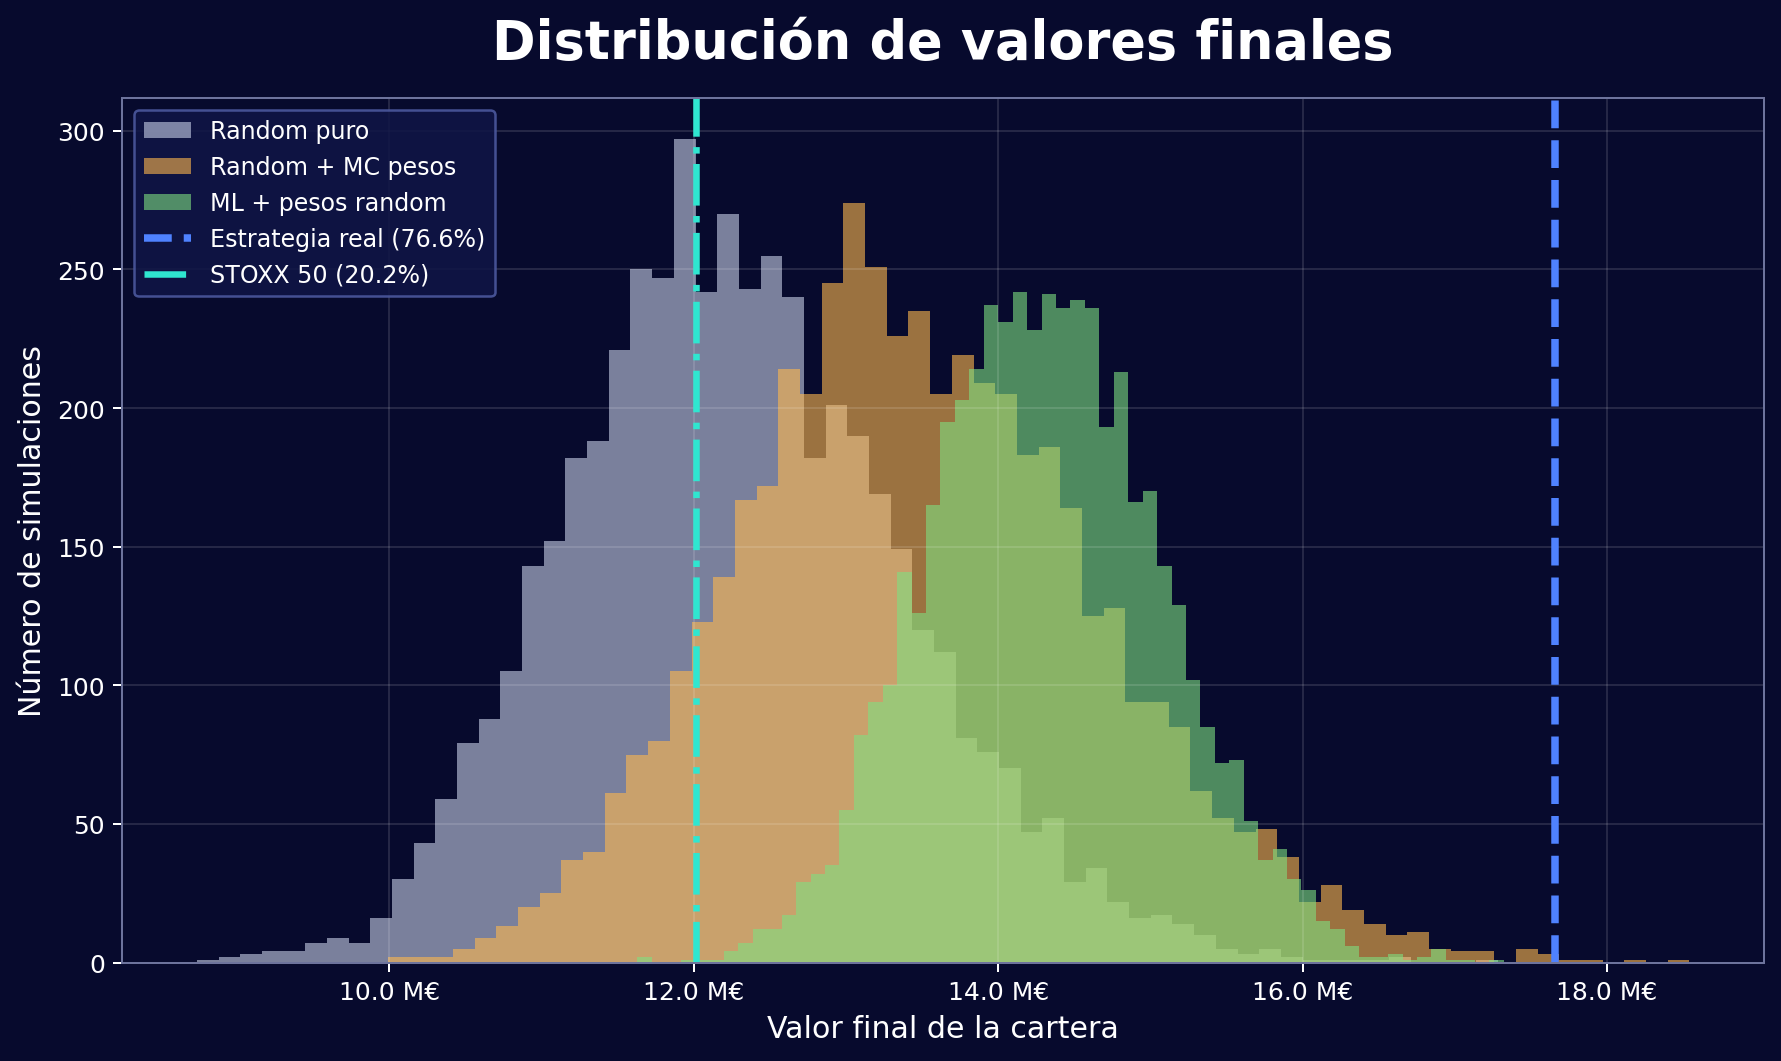

In [23]:
# Histograma
fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
fig.patch.set_facecolor(fondo)
ax.set_facecolor(fondo)

ax.hist(
    final_random,
    bins=60,
    alpha=0.6,
    label="Random puro",
    color=gris,
)

ax.hist(
    final_mc,
    bins=60,
    alpha=0.6,
    label="Random + MC pesos",
    color=naranja,
)

ax.hist(
    final_ml_random,
    bins=60,
    alpha=0.6,
    label="ML + pesos random",
    color=verde,
)

# Estrategia real
rent_real = valor_final_real / nominal - 1
ax.axvline(
    valor_final_real,
    color=azul,
    linewidth=3.0,
    linestyle="--",
    label=f"Estrategia real ({rent_real:.1%})",
)

# Benchmark / índice
if "benchmark" in res_random:
    benchmark = res_random["benchmark"].reindex(idx).ffill()
    valor_final_bmk = benchmark.iloc[-1]
    rent_bmk = valor_final_bmk / nominal - 1

    ax.axvline(
        valor_final_bmk,
        color=turquesa,
        linewidth=2.6,
        linestyle="-.",
        label=f"STOXX 50 ({rent_bmk:.1%})",
    )

ax.set_title(
    "Distribución de valores finales",
    color=blanco,
    fontsize=21,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel("Valor final de la cartera", color=blanco, fontsize=12)
ax.set_ylabel("Número de simulaciones", color=blanco, fontsize=12)
ax.xaxis.set_major_formatter(FuncFormatter(formato_euros_millones))

ax.grid(True, color=blanco, alpha=0.12, linewidth=0.8)
ax.tick_params(colors=blanco, labelsize=10)

for spine in ax.spines.values():
    spine.set_color("#6D739C")

leg = ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=9.5,
)

leg.get_frame().set_facecolor("#101545")
leg.get_frame().set_edgecolor("#4D5AA0")
leg.get_frame().set_alpha(0.88)

for text in leg.get_texts():
    text.set_color(blanco)

plt.tight_layout()
plt.show()

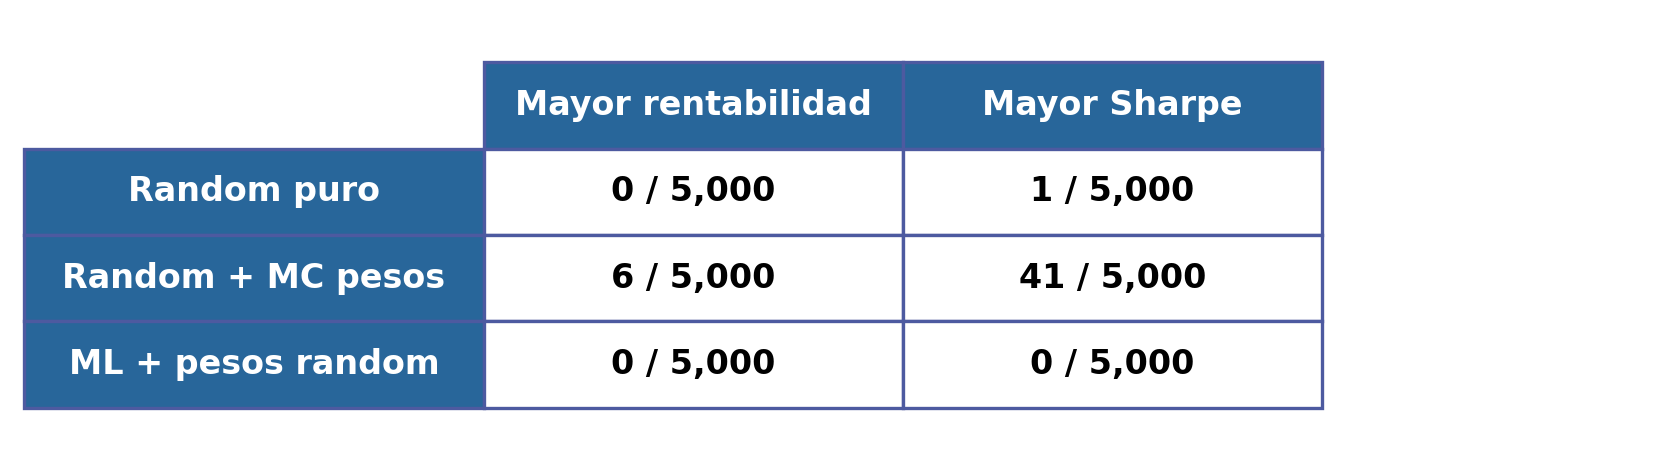

In [38]:
import matplotlib.pyplot as plt

tabla_slide = pd.DataFrame({
    "Mayor rentabilidad": [
        f"{int((rent_random > rent_real).sum()):,} / {len(rent_random):,}",
        f"{int((rent_mc > rent_real).sum()):,} / {len(rent_mc):,}",
        f"{int((rent_ml_random > rent_real).sum()):,} / {len(rent_ml_random):,}",
    ],
    "Mayor Sharpe": [
        f"{int((sharpe_random > sharpe_real).sum()):,} / {len(sharpe_random):,}",
        f"{int((sharpe_mc > sharpe_real).sum()):,} / {len(sharpe_mc):,}",
        f"{int((sharpe_ml_random > sharpe_real).sum()):,} / {len(sharpe_ml_random):,}",
    ],
}, index=[
    "Random puro",
    "Random + MC pesos",
    "ML + pesos random",
])

header = "#28669A"
fila = "white"
borde = "#4D5AA0"
texto = "black"
texto_header = "white"

fig, ax = plt.subplots(figsize=(7.0, 1.8), dpi=240)
ax.axis("off")

table = ax.table(
    cellText=tabla_slide.values,
    rowLabels=tabla_slide.index,
    colLabels=tabla_slide.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center",
    colWidths=[0.28, 0.28],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.7)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(borde)
    cell.set_linewidth(1.0)

    if row == 0:
        cell.set_facecolor(header)
        cell.set_text_props(color=texto_header, weight="bold")
    elif col == -1:
        cell.set_facecolor(header)
        cell.set_text_props(color=texto_header, weight="bold")
    else:
        cell.set_facecolor(fila)
        cell.set_text_props(color=texto, weight="bold")

plt.tight_layout(pad=0.15)
plt.show()